# Árboles de decisión: greedy vs óptimo, paso a paso

Un árbol de decisión hace visible una estrategia dinámica: cada nodo es una
prueba, cada rama es un conteo observado, y cada camino de la raíz a una hoja
es un escenario posible. Aquí se dibujan verticales, con la **ruta que de
verdad se recorre** resaltada para un perfil concreto, y se ponen el greedy y
el óptimo **lado a lado** sobre una instancia chica donde eligen distinto — para
ver, no deducir, por qué el óptimo gana.

Cómo leerlo: primero qué es un árbol (§1), luego la comparación greedy vs
óptimo y dónde divergen (§2). Cada número se regenera aquí; nada escrito a
mano.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import io, random
import matplotlib.pyplot as plt

from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_expected_utility
from augmented.tree_extractor import extract_tree, GreedyPolicy
from augmented.tree_visualizer import render_tree_path
from augmented.core import test_result, indices_from_mask, mask_str

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# --- instancia chica donde greedy y óptimo divergen (n=4, B=2, G=2) ---
rng = random.Random(185)
n, B, G = 4, 2, 2
p = [rng.uniform(0.15, 0.7) for _ in range(n)]
u = [rng.uniform(1.0, 4.0) for _ in range(n)]

def tree_img(dot):
    '''Renderiza un árbol graphviz a imagen (PNG) para que sobreviva al PDF.'''
    return plt.imread(io.BytesIO(dot.pipe(format='png')))

def realized_utility(tree, z):
    '''Sigue la ruta que el perfil z induce (por conteos) hasta la hoja.'''
    node = tree
    while not node.get('terminal'):
        node = node['children'][test_result(node['pool'], z)]
    return node['utility']

print(f'instancia n={n} B={B} G={G}')
print('p =', [round(x, 3) for x in p])
print('u =', [round(x, 3) for x in u])

instancia n=4 B=2 G=2
p = [0.645, 0.593, 0.233, 0.314]
u = [2.778, 2.428, 2.204, 1.004]


## 1. Qué es un árbol de decisión

**Intuición.** Imagina que juegas la estrategia dinámica en tiempo real. Empiezas
en la raíz: pruebas un pool. La prueba te devuelve un conteo —cuántos infectados
había— y según ese número bajas por una rama distinta. Ahí vuelves a decidir qué
pool probar, y así hasta gastar el presupuesto. Cada hoja es un desenlace:
a quién certificaste sano y cuánta utilidad juntaste.

Un perfil latente concreto (quién está de verdad infectado) selecciona **una
sola ruta** por el árbol: en cada nodo, el conteo que sale es determinista dado
el perfil. Esa es la ruta que resaltamos.

**Afirmación.** El árbol del óptimo, en esta instancia chica, cabe entero
en una figura; resaltando la ruta de un perfil se ve exactamente qué prueba en
cada paso y qué certifica al final.

In [2]:
opt_val, opt_pol = solve_optimal_dapts(p, u, B, G)
tree_opt = extract_tree(opt_pol, p, u, n)

# perfil que usaremos para resaltar: personas 1 y 2 infectadas
z = 0b0110
assert indices_from_mask(z, n) == [1, 2]

# autoverificación: la utilidad al seguir la ruta de z coincide con la hoja
leaf = realized_utility(tree_opt, z)
node = tree_opt
while not node.get('terminal'):
    node = node['children'][test_result(node['pool'], z)]
assert abs(leaf - node['utility']) < 1e-12
print(f'óptimo: valor esperado {opt_val:.3f}; primer pool que prueba: '
      f'{mask_str(tree_opt["pool"], n)}')
print(f'sobre el perfil z={z:04b} (infectados {indices_from_mask(z, n)}): '
      f'el óptimo certifica utilidad {leaf:.2f}')

óptimo: valor esperado 2.892; primer pool que prueba: {1,2}
sobre el perfil z=0110 (infectados [1, 2]): el óptimo certifica utilidad 2.78


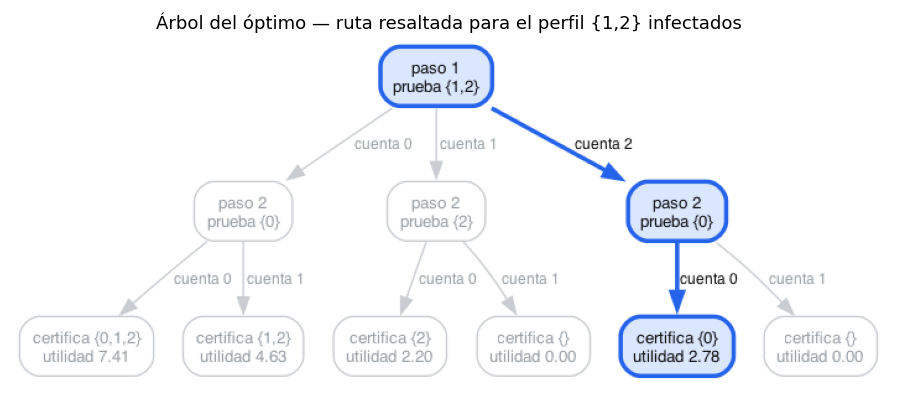

In [3]:
dot = render_tree_path(tree_opt, n, z, title=None)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(tree_img(dot)); ax.axis('off')
ax.set_title('Árbol del óptimo — ruta resaltada para el perfil {1,2} infectados',
             fontsize=10)
fig.tight_layout(); plt.show()

**Lectura.** La ruta azul es lo que pasa cuando las personas 1 y 2 están
infectadas: en cada paso, el pool probado y el conteo que sale (la etiqueta de
la arista) determinan hacia dónde sigue. Las ramas grises son los otros
desenlaces que no ocurrieron con este perfil, pero que la estrategia tenía
listos. El árbol es la política completa; la ruta es una jugada.

**Para discutir.** ¿Conviene leer estos árboles por profundidad (qué se
prueba primero) o por hoja (qué desenlaces certifican más)? Para el paper,
¿cuál de las dos vistas comunica mejor la ventaja del conteo?

## 2. Greedy vs óptimo: dónde divergen

**Intuición.** El greedy es miope: en cada paso elige el pool que se ve mejor
*ahora*, sin pensar en el siguiente. El óptimo mira todo el horizonte. Si los
dos eligieran siempre el mismo pool, sus árboles serían idénticos. No lo son — y
el primer lugar donde difieren, la raíz, es donde se juega el gap.

**Afirmación.** En esta instancia el greedy y el óptimo prueban un pool
distinto ya en la raíz, y sobre el perfil {1,2} eso cuesta todo: el óptimo
certifica utilidad, el greedy se queda en cero.

In [4]:
grd_pol = GreedyPolicy(p, u, G, B)
tree_grd = extract_tree(grd_pol, p, u, n)
grd_val = greedy_myopic_expected_utility(p, u, B, G)

# autoverificación de la jerarquía: greedy <= óptimo (en valor esperado)
assert grd_val <= opt_val + 1e-9

r_opt = realized_utility(tree_opt, z)
r_grd = realized_utility(tree_grd, z)
print(f'raíz — óptimo prueba {mask_str(tree_opt["pool"], n)}, '
      f'greedy prueba {mask_str(tree_grd["pool"], n)}')
print(f'valor esperado — óptimo {opt_val:.3f}, greedy {grd_val:.3f} '
      f'(gap {100*(opt_val-grd_val)/opt_val:.1f}%)')
print(f'sobre el perfil z={z:04b} — óptimo {r_opt:.2f}, greedy {r_grd:.2f}')

raíz — óptimo prueba {1,2}, greedy prueba {2}
valor esperado — óptimo 2.892, greedy 2.679 (gap 7.4%)
sobre el perfil z=0110 — óptimo 2.78, greedy 0.00


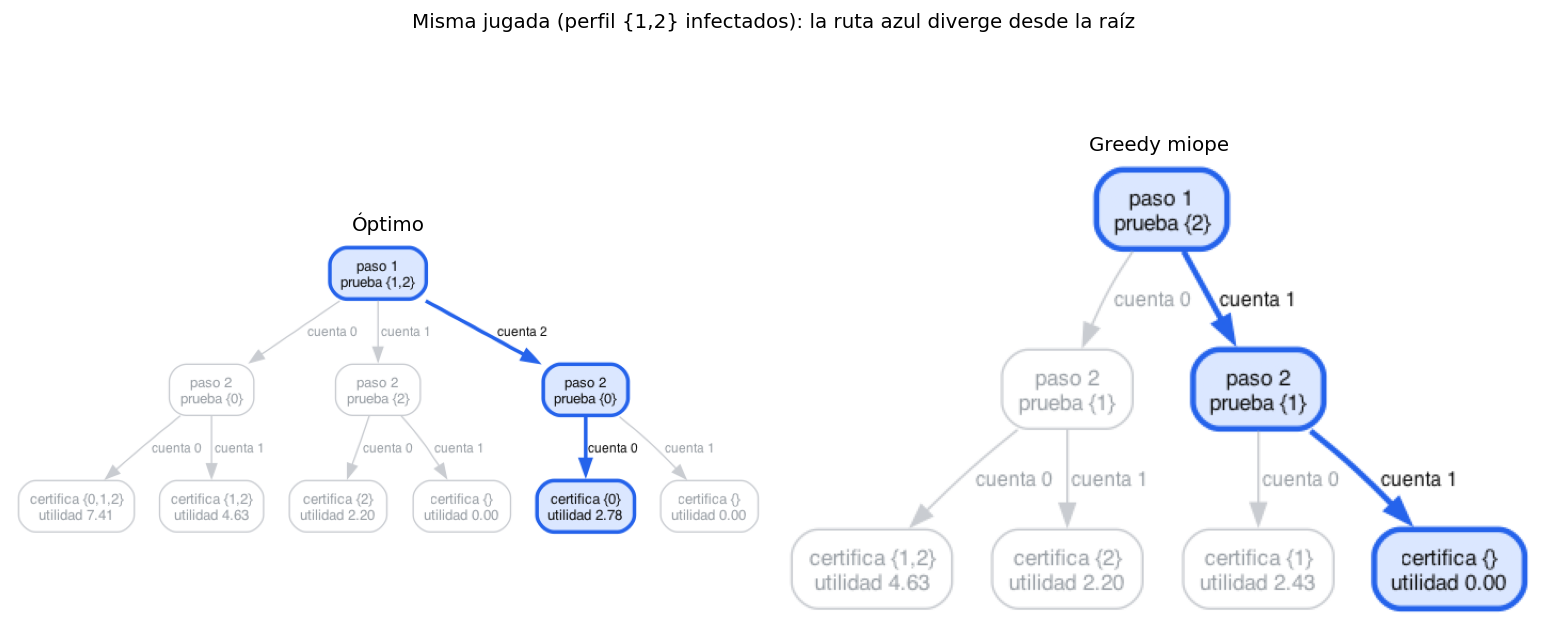

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, tree, name in [(axes[0], tree_opt, 'Óptimo'),
                       (axes[1], tree_grd, 'Greedy miope')]:
    ax.imshow(tree_img(render_tree_path(tree, n, z, title=None)))
    ax.axis('off'); ax.set_title(name, fontsize=11)
fig.suptitle('Misma jugada (perfil {1,2} infectados): la ruta azul diverge '
             'desde la raíz', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

**Lectura.** Mira las dos raíces: el óptimo abre probando el par, que le da
más información para el segundo paso; el greedy abre probando a la persona que
*sola* se ve más valiosa, y en este perfil eso lo deja sin poder certificar a
nadie —utilidad cero— mientras el óptimo recupera. El gap agregado (~7%) es
pequeño en promedio, pero perfiles como este lo explican: la miopía se paga en
los escenarios donde el primer paso tenía que preparar el segundo.

**Para discutir.** Esta divergencia es de primer paso, justo la "ley del
lookahead": un paso de anticipación cerraría este caso. ¿Vale la pena, para el
paper, un panel de árboles como este —greedy vs óptimo con la ruta que más
separa— como la figura que *muestra* de dónde sale el hueco del greedy, en vez
de solo reportar el número?